# RubanRose — Fine-tuning ViT-Small & ConvNeXt-Tiny

Optimisation des hyperparamètres par **Optuna** (30 trials / modèle) sur **CPU**.

| Modèle | Source | Pré-entraînement |
|---|---|---|
| ViT-Small patch16/224 | timm | ImageNet-21k |
| ConvNeXt-Tiny 224 | HuggingFace | ImageNet-1k |

**Espace de recherche** : `lr`, `weight_decay`, `batch_size`, `dropout`, + spécifique (`drop_path_rate` / `layer_decay`) + stratégie de dégel catégorielle.

**Données** : `data/split_breakhis.csv` — toutes magnifications, 100 % des données, augmentation pyramide de rigueur sur le train.

In [ ]:
import os, torch

CSV_PATH    = "data/split_breakhis.csv"
MODELS_DIR  = "models"
RESULTS_DIR = "results"

HPO_EPOCHS          = 3
N_TRIALS            = 30
PRUNE_WARMUP_TRIALS = 5
PRUNE_WARMUP_STEPS  = 1

FINAL_EPOCHS = 20

OPTUNA_DB = f"sqlite:///{RESULTS_DIR}/optuna.db"

DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"
N_WORKERS = 0

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
CROP_SIZE     = 224
RESIZE        = 256

AUG_TIERS = {
    "ductal_carcinoma"    : "leger",
    "fibroadenoma"        : "leger",
    "mucinous_carcinoma"  : "modere",
    "papillary_carcinoma" : "modere",
    "adenosis"            : "intensif",
    "lobular_carcinoma"   : "intensif",
    "phyllodes_tumor"     : "intensif",
    "tubular_adenoma"     : "intensif",
}

SEED = 42
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Device          : {DEVICE}")
print(f"Dossier resultats: {RESULTS_DIR}/")
print(f"Optuna DB       : {OPTUNA_DB}")

Device          : cpu
Dossier resultats: results/
Optuna DB       : sqlite:///results/optuna.db


In [ ]:
import subprocess, sys

REQUIRED = ["torch", "timm", "transformers", "optuna", "sklearn", "pandas", "PIL"]
missing  = []
for pkg in REQUIRED:
    try:
        __import__(pkg if pkg != "PIL" else "PIL.Image")
    except ImportError:
        missing.append(pkg)

if missing:
    print(f"Packages manquants: {missing}")
    print("Executer : pip install -r requirements.txt")
else:
    print("Tous les packages sont disponibles.")

Tous les packages sont disponibles.


In [ ]:
import random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image, ImageOps, ImageEnhance, ImageFilter

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import timm
from transformers import ConvNextForImageClassification

import optuna
from optuna.pruners import MedianPruner
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("Imports OK")

Imports OK


In [ ]:
# ── Pyramide d'augmentation (reprise de l'AED) ────────────────────────────────

def augLight(img: Image.Image) -> Image.Image:
    """Leger (x2) : Flips H/V. Classes dominantes."""
    if random.random() > 0.5: img = ImageOps.mirror(img)
    if random.random() > 0.5: img = ImageOps.flip(img)
    return img

def augModerate(img: Image.Image) -> Image.Image:
    """Modere (x4) : Flips + Rotations 90deg + ColorJitter."""
    img = augLight(img)
    img = img.rotate(random.choice([0, 90, 180, 270]))
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.80, 1.20))
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.85, 1.15))
    return img

def augIntensive(img: Image.Image) -> Image.Image:
    """Intensif (x10) : Flips + Rotations + RandomResizedCrop + GaussianBlur."""
    img = augModerate(img)
    W, H  = img.size
    scale = random.uniform(0.30, 0.90)
    cw    = max(int(W * scale), 64)
    ch    = max(int(H * scale), 64)
    x     = random.randint(0, W - cw)
    y     = random.randint(0, H - ch)
    img   = img.crop((x, y, x + cw, y + ch)).resize((W, H), Image.LANCZOS)
    img   = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.1, 1.2)))
    return img

AUG_FN = {"leger": augLight, "modere": augModerate, "intensif": augIntensive}

print("Fonctions d'augmentation definies : augLight, augModerate, augIntensive")

Fonctions d'augmentation definies : augLight, augModerate, augIntensive


In [ ]:
class BreakHisDataset(Dataset):
    """Dataset BreakHis charge depuis split_breakhis.csv.

    - split='train' + augment=True : augmentation pyramide de rigueur + RandomResizedCrop
    - split='val'/'test'           : Resize(256) + CenterCrop(224) deterministe
    """

    _trainTf = T.Compose([
        T.RandomResizedCrop(CROP_SIZE, scale=(0.2, 1.0)),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    _valTf = T.Compose([
        T.Resize(RESIZE),
        T.CenterCrop(CROP_SIZE),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

    def __init__(self, csvPath: str, split: str, augment: bool = False):
        df = pd.read_csv(csvPath)
        self.records = df[df["split"] == split].reset_index(drop=True)
        self.augment  = augment

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, idx):
        r   = self.records.iloc[idx]
        img = Image.open(r["imagePath"]).convert("RGB")
        if self.augment:
            tier = AUG_TIERS.get(r["subtype"], "leger")
            img  = AUG_FN[tier](img)
            img  = self._trainTf(img)
        else:
            img = self._valTf(img)
        return img, int(r["label"])

print("BreakHisDataset defini")

BreakHisDataset defini


In [ ]:
# ── Datasets ─────────────────────────────────────────────────────────────────
trainDs = BreakHisDataset(CSV_PATH, "train", augment=True)
valDs   = BreakHisDataset(CSV_PATH, "val",   augment=False)
testDs  = BreakHisDataset(CSV_PATH, "test",  augment=False)

print(f"Train : {len(trainDs):,} images (avec augmentation)")
print(f"Val   : {len(valDs):,}  images")
print(f"Test  : {len(testDs):,}  images")

# ── Poids de classe (calcules sur train uniquement, sans augmentation) ────────
trainDfRaw  = pd.read_csv(CSV_PATH)
trainLabels = trainDfRaw[trainDfRaw["split"] == "train"]["label"].values
cwValues    = compute_class_weight("balanced", classes=np.array([0, 1]), y=trainLabels)
classWeightTensor = torch.tensor(cwValues, dtype=torch.float32).to(DEVICE)

nBenin = (trainLabels == 0).sum()
nMalin = (trainLabels == 1).sum()
print(f"\nPoids de classe (train) :")
print(f"  Benin  (0) : {nBenin:,} images  poids = {cwValues[0]:.4f}")
print(f"  Malin  (1) : {nMalin:,} images  poids = {cwValues[1]:.4f}")

# ── DataLoaders val/test (batch_size fixe, pas de shuffle) ───────────────────
valLoader  = DataLoader(valDs,  batch_size=16, shuffle=False, num_workers=N_WORKERS)
testLoader = DataLoader(testDs, batch_size=16, shuffle=False, num_workers=N_WORKERS)

Train : 5,526 images (avec augmentation)
Val   : 1,063  images
Test  : 1,320  images

Poids de classe (train) :
  Benin  (0) : 1,695 images  poids = 1.6301
  Malin  (1) : 3,831 images  poids = 0.7212


## Factories de modèles

**Stratégie de dégel — 3 choix catégoriels**

| Stratégie | ConvNeXt-Tiny | ViT-Small |
|---|---|---|
| `unfreeze_head_only` | Tout gelé sauf classifier | Tout gelé sauf head |
| `unfreeze_last_stage` | Stage[-1] + classifier | Blocs[-4:] + head |
| `unfreeze_all` | Tout le réseau | Tout le réseau |

**Layer Decay (ViT uniquement)** : `lr_i = baseLr × layerDecay^(n_blocks − i)` — les couches proches de l'entrée reçoivent un lr plus faible, protégeant les features basses fréquences.

In [ ]:
def build_convnext(
    dropPathRate: float = 0.1,
    dropoutRate:  float = 0.2,
    unfreezeStrategy: str = "unfreeze_last_stage",
) -> nn.Module:
    """ConvNeXt-Tiny depuis models/convnext_tiny_224.
    Remplace le classifier par Dropout + Linear pour permettre le tuning du dropout.
    Applique le drop_path_rate sur tous les modules DropPath.
    """
    model = ConvNextForImageClassification.from_pretrained(
        f"{MODELS_DIR}/convnext_tiny_224",
        ignore_mismatched_sizes=True,
        num_labels=2,
    )
    # Remplacement du classifier pour integrer le dropout
    inFeatures = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropoutRate),
        nn.Linear(inFeatures, 2),
    )
    # Stochastic Depth : on cible les modules avec drop_prob
    for mod in model.modules():
        if hasattr(mod, "drop_prob"):
            mod.drop_prob = dropPathRate
    # Gel total
    for p in model.parameters():
        p.requires_grad = False
    # Strategie de decongelation
    if unfreezeStrategy == "unfreeze_last_stage":
        unfreezeMods = [model.convnext.encoder.stages[-1]]
    elif unfreezeStrategy == "unfreeze_all":
        unfreezeMods = [model.convnext.encoder, model.convnext.layernorm]
    else:
        unfreezeMods = []
    for mod in unfreezeMods:
        for p in mod.parameters():
            p.requires_grad = True
    # Classifier toujours decongle
    for p in model.classifier.parameters():
        p.requires_grad = True
    nTrainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    nTotal     = sum(p.numel() for p in model.parameters())
    print(f"  ConvNeXt [{unfreezeStrategy}] : {nTrainable:,} / {nTotal:,} params entrainables")
    return model


def build_vit(
    dropoutRate:      float = 0.1,
    layerDecay:       float = 0.75,
    unfreezeStrategy: str   = "unfreeze_last_stage",
) -> nn.Module:
    """ViT-Small patch16/224 depuis models/vit_small_patch16_224_augreg_in21k.pth.
    drop_rate controle le dropout dans les MLP des blocs transformer.
    """
    model = timm.create_model(
        "vit_small_patch16_224.augreg_in21k",
        pretrained=False,
        num_classes=2,
        drop_rate=dropoutRate,
    )
    # Le checkpoint in21k embarque une head a 21843 classes : on ecarte les
    # poids head.* pour conserver la head 2 classes fraichement initialisee.
    # (strict=False ne tolere PAS un mismatch de taille, seulement les cles manquantes.)
    state = torch.load(
        f"{MODELS_DIR}/vit_small_patch16_224_augreg_in21k.pth",
        map_location="cpu",
    )
    state = {k: v for k, v in state.items() if not k.startswith("head.")}
    model.load_state_dict(state, strict=False)
    # Gel total
    for p in model.parameters():
        p.requires_grad = False
    # Strategie de decongelation
    if unfreezeStrategy == "unfreeze_last_stage":
        unfreezeMods = list(model.blocks[-4:])
    elif unfreezeStrategy == "unfreeze_all":
        unfreezeMods = list(model.blocks) + [model.patch_embed, model.norm]
    else:
        unfreezeMods = []
    for mod in unfreezeMods:
        for p in mod.parameters():
            p.requires_grad = True
    # Head toujours decongele
    for p in model.head.parameters():
        p.requires_grad = True
    nTrainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    nTotal     = sum(p.numel() for p in model.parameters())
    print(f"  ViT [{unfreezeStrategy}] : {nTrainable:,} / {nTotal:,} params entrainables")
    return model


def makeVitParamGroups(model: nn.Module, baseLr: float, layerDecay: float) -> list:
    """Layer-wise LR decay pour ViT : lr_i = baseLr * layerDecay^(n_blocks - i).
    Seuls les parametres avec requires_grad=True sont inclus.
    """
    nBlocks = len(model.blocks)
    groups  = []
    for i, blk in enumerate(model.blocks):
        params = [p for p in blk.parameters() if p.requires_grad]
        if params:
            lrI = baseLr * (layerDecay ** (nBlocks - i))
            groups.append({"params": params, "lr": lrI})
    headParams = [p for p in model.head.parameters() if p.requires_grad]
    if headParams:
        groups.append({"params": headParams, "lr": baseLr})
    if not groups:
        groups = [{"params": list(model.head.parameters()), "lr": baseLr}]
    return groups


print("Factories definies : build_convnext, build_vit, makeVitParamGroups")

Factories definies : build_convnext, build_vit, makeVitParamGroups


In [ ]:
def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer,
    weightTensor: torch.Tensor,
) -> float:
    """Une epoch d'entrainement. Retourne la loss moyenne."""
    model.train()
    criterion = nn.CrossEntropyLoss(weight=weightTensor)
    totalLoss = 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out    = model(imgs)
        logits = out.logits if hasattr(out, "logits") else out
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        totalLoss += loss.item()
    return totalLoss / max(len(loader), 1)


def eval_epoch(model: nn.Module, loader: DataLoader) -> float:
    """Evaluation : retourne le F1-score macro (metrique de reference anti-desequilibre)."""
    model.eval()
    allPreds, allLabels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE)
            out    = model(imgs)
            logits = out.logits if hasattr(out, "logits") else out
            preds  = logits.argmax(dim=1).cpu().numpy()
            allPreds.extend(preds)
            allLabels.extend(labels.numpy())
    return f1_score(allLabels, allPreds, average="macro", zero_division=0)


print("Fonctions train_epoch et eval_epoch definies")

Fonctions train_epoch et eval_epoch definies


## Optimisation Optuna — ConvNeXt-Tiny

**Espace de recherche (6 paramètres)** :

| Paramètre | Type | Plage |
|---|---|---|
| `lr` | float log | 1e-5 → 5e-4 |
| `weight_decay` | float log | 1e-6 → 1e-2 |
| `batch_size` | catégoriel | 8, 16 |
| `dropout` | float | 0.0 → 0.4 |
| `drop_path_rate` | float | 0.0 → 0.3 |
| `unfreeze_strategy` | catégoriel | 3 choix |

**Pruning** : `MedianPruner(n_startup_trials=5, n_warmup_steps=1)` — coupe les essais dont le F1 à l'epoch 1 est sous la médiane des essais précédents.

In [ ]:
def objectiveConvnext(trial: optuna.Trial) -> float:
    lr               = trial.suggest_float("lr",           1e-5,  5e-4, log=True)
    weightDecay      = trial.suggest_float("weight_decay", 1e-6,  1e-2, log=True)
    batchSize        = trial.suggest_categorical("batch_size", [8, 16])
    dropoutRate      = trial.suggest_float("dropout",       0.0,  0.4)
    dropPathRate     = trial.suggest_float("drop_path_rate",0.0,  0.3)
    unfreezeStrategy = trial.suggest_categorical(
        "unfreeze_strategy",
        ["unfreeze_head_only", "unfreeze_last_stage", "unfreeze_all"]
    )
    torch.manual_seed(SEED)
    model     = build_convnext(dropPathRate, dropoutRate, unfreezeStrategy).to(DEVICE)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weightDecay)
    loader    = DataLoader(trainDs, batch_size=batchSize, shuffle=True,
                           num_workers=N_WORKERS)
    valF1 = 0.0
    for epoch in range(HPO_EPOCHS):
        train_epoch(model, loader, optimizer, classWeightTensor)
        valF1 = eval_epoch(model, valLoader)
        trial.report(valF1, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return valF1


# Un essai "fait" = evalue jusqu'au bout (COMPLETE) OU coupe par le pruner (PRUNED).
# Les deux consomment le budget de N_TRIALS ; seuls les FAIL (crash/bug) sont a refaire.
DONE_STATES = (optuna.trial.TrialState.COMPLETE, optuna.trial.TrialState.PRUNED)


def countDone(study) -> int:
    return len([t for t in study.trials if t.state in DONE_STATES])


prunerConvnext = MedianPruner(
    n_startup_trials=PRUNE_WARMUP_TRIALS,
    n_warmup_steps=PRUNE_WARMUP_STEPS,
)
convnextStudy = optuna.create_study(
    study_name="convnext_breakhis",
    direction="maximize",
    pruner=prunerConvnext,
    sampler=optuna.samplers.TPESampler(seed=SEED),
    storage=OPTUNA_DB,
    load_if_exists=True,
)
nDone = countDone(convnextStudy)
print(f"Study ConvNeXt charge — {nDone}/{N_TRIALS} trials deja faits (completes + elagues)")

Study ConvNeXt charge — 41/30 trials deja faits (completes + elagues)


In [ ]:
nDone      = countDone(convnextStudy)
nRemaining = max(0, N_TRIALS - nDone)

if nRemaining == 0:
    print(f"Study ConvNeXt deja complete ({nDone}/{N_TRIALS} trials faits). Aucun trial supplementaire.")
else:
    print(f"=== HPO ConvNeXt-Tiny : {nRemaining} trials restants ({nDone}/{N_TRIALS} deja faits) ===")
    convnextStudy.optimize(objectiveConvnext, n_trials=nRemaining, show_progress_bar=True)

bestConvnext = convnextStudy.best_trial
print(f"\nMeilleur trial : #{bestConvnext.number}  Val F1 = {bestConvnext.value:.4f}")
print("Parametres :")
for k, v in bestConvnext.params.items():
    print(f"  {k:25s} : {v}")

Study ConvNeXt deja complete (41/30 trials faits). Aucun trial supplementaire.

Meilleur trial : #52  Val F1 = 0.7835
Parametres :
  lr                        : 0.00047823741124726195
  weight_decay              : 0.00041311599481885043
  batch_size                : 8
  dropout                   : 0.22589527406475396
  drop_path_rate            : 0.22545921091830337
  unfreeze_strategy         : unfreeze_all


## Optimisation Optuna — ViT-Small

**Espace de recherche (6 paramètres)** :

| Paramètre | Type | Plage |
|---|---|---|
| `lr` | float log | 1e-5 → 5e-4 |
| `weight_decay` | float log | 1e-6 → 1e-2 |
| `batch_size` | catégoriel | 8, 16 |
| `dropout` | float | 0.0 → 0.4 |
| `layer_decay` | float | 0.65 → 0.95 |
| `unfreeze_strategy` | catégoriel | 3 choix |

**Layer-wise LR Decay** : les couches les plus proches de l'entrée reçoivent un lr plus faible (`lr_i = lr × layer_decay^(n_blocks − i)`), protégeant les features génériques pré-entraînées.

In [ ]:
def objectiveVit(trial: optuna.Trial) -> float:
    lr               = trial.suggest_float("lr",           1e-5,  5e-4, log=True)
    weightDecay      = trial.suggest_float("weight_decay", 1e-6,  1e-2, log=True)
    batchSize        = trial.suggest_categorical("batch_size", [8, 16])
    dropoutRate      = trial.suggest_float("dropout",       0.0,  0.4)
    layerDecay       = trial.suggest_float("layer_decay",   0.65, 0.95)
    unfreezeStrategy = trial.suggest_categorical(
        "unfreeze_strategy",
        ["unfreeze_head_only", "unfreeze_last_stage", "unfreeze_all"]
    )
    torch.manual_seed(SEED)
    model       = build_vit(dropoutRate, layerDecay, unfreezeStrategy).to(DEVICE)
    paramGroups = makeVitParamGroups(model, lr, layerDecay)
    optimizer   = AdamW(paramGroups, weight_decay=weightDecay)
    loader      = DataLoader(trainDs, batch_size=batchSize, shuffle=True,
                             num_workers=N_WORKERS)
    valF1 = 0.0
    for epoch in range(HPO_EPOCHS):
        train_epoch(model, loader, optimizer, classWeightTensor)
        valF1 = eval_epoch(model, valLoader)
        trial.report(valF1, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return valF1


prunerVit = MedianPruner(
    n_startup_trials=PRUNE_WARMUP_TRIALS,
    n_warmup_steps=PRUNE_WARMUP_STEPS,
)
vitStudy = optuna.create_study(
    study_name="vit_breakhis",
    direction="maximize",
    pruner=prunerVit,
    sampler=optuna.samplers.TPESampler(seed=SEED),
    storage=OPTUNA_DB,
    load_if_exists=True,
)
nDone = countDone(vitStudy)
print(f"Study ViT charge — {nDone}/{N_TRIALS} trials deja faits (completes + elagues)")

Study ViT charge — 30/30 trials deja faits (completes + elagues)


In [ ]:
nDone      = countDone(vitStudy)
nRemaining = max(0, N_TRIALS - nDone)

if nRemaining == 0:
    print(f"Study ViT deja complete ({nDone}/{N_TRIALS} trials faits). Aucun trial supplementaire.")
else:
    print(f"=== HPO ViT-Small : {nRemaining} trials restants ({nDone}/{N_TRIALS} deja faits) ===")
    vitStudy.optimize(objectiveVit, n_trials=nRemaining, show_progress_bar=True)

bestVit = vitStudy.best_trial
print(f"\nMeilleur trial : #{bestVit.number}  Val F1 = {bestVit.value:.4f}")
print("Parametres :")
for k, v in bestVit.params.items():
    print(f"  {k:25s} : {v}")

Study ViT deja complete (30/30 trials faits). Aucun trial supplementaire.

Meilleur trial : #15  Val F1 = 0.8035
Parametres :
  lr                        : 0.00023774322820018174
  weight_decay              : 0.0001097400572535479
  batch_size                : 16
  dropout                   : 0.3934902715726638
  layer_decay               : 0.8797655517229184
  unfreeze_strategy         : unfreeze_all


Modele,ConvNeXt-Tiny,ViT-Small
Trials completes,41,30
Trials elagues,12,1
Meilleur Val F1,0.7835,0.8035
lr,0.00047823741124726195,0.00023774322820018174
weight_decay,0.00041311599481885043,0.0001097400572535479
batch_size,8,16
dropout,0.22589527406475396,0.3934902715726638
drop_path_rate,0.22545921091830337,NaN
unfreeze_strategy,unfreeze_all,unfreeze_all
layer_decay,NaN,0.8797655517229184


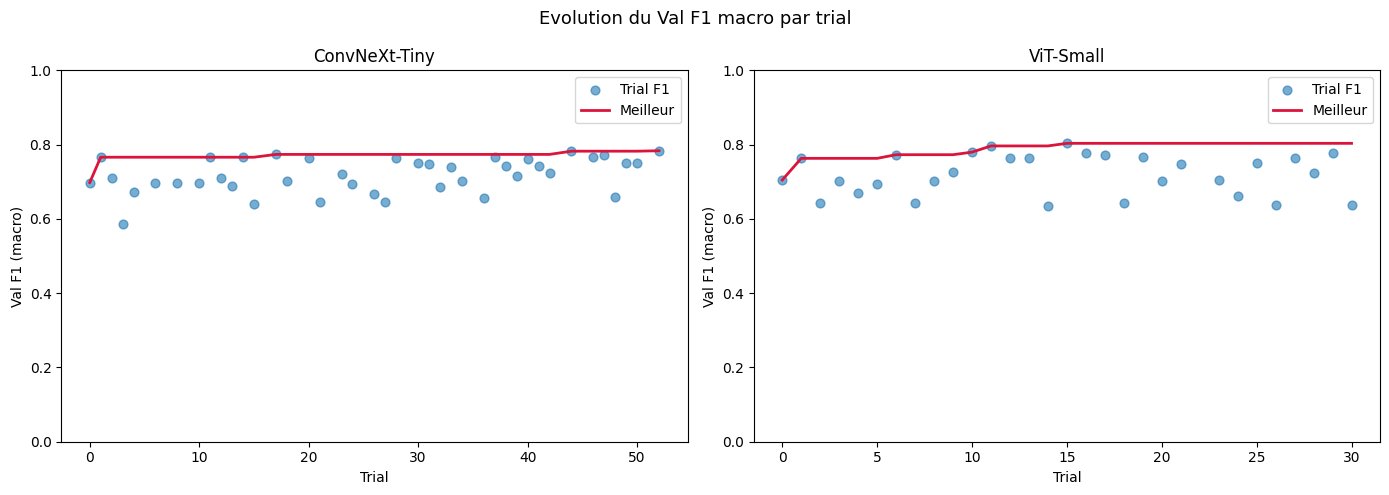

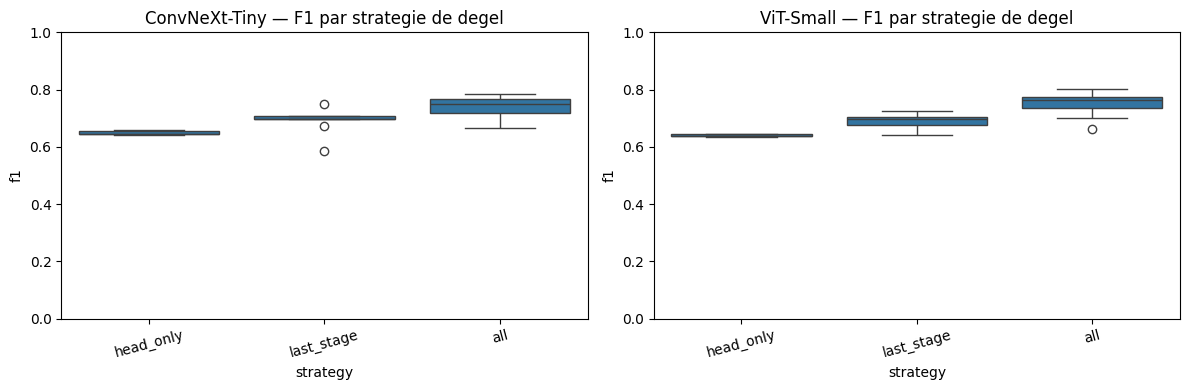

In [ ]:
# ── Comparaison ConvNeXt vs ViT ───────────────────────────────────────────────

studies   = [(convnextStudy, "ConvNeXt-Tiny"), (vitStudy, "ViT-Small")]
summaryRows = []

for study, name in studies:
    completed = [t for t in study.trials if t.value is not None]
    pruned    = [t for t in study.trials if t.value is None]
    summaryRows.append({
        "Modele":          name,
        "Trials completes": len(completed),
        "Trials elagues":  len(pruned),
        "Meilleur Val F1": f"{study.best_value:.4f}",
        **{k: str(v) for k, v in study.best_params.items()},
    })

from IPython.display import display
display(pd.DataFrame(summaryRows).set_index("Modele").T)

# ── Graphe : Val F1 par trial ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (study, title) in zip(axes, studies):
    completed = [t for t in study.trials if t.value is not None]
    nums   = [t.number for t in completed]
    vals   = [t.value  for t in completed]
    best   = [max(vals[:i+1]) for i in range(len(vals))]
    ax.scatter(nums, vals, alpha=0.6, s=40, label="Trial F1")
    ax.plot(nums, best, color="crimson", linewidth=2, label="Meilleur")
    ax.set_xlabel("Trial")
    ax.set_ylabel("Val F1 (macro)")
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(0, 1)
plt.suptitle("Evolution du Val F1 macro par trial", fontsize=13)
plt.tight_layout()
plt.show()

# ── Graphe : distribution des strategies de degel ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (study, title) in zip(axes, studies):
    completed = [t for t in study.trials if t.value is not None]
    strategies = [t.params.get("unfreeze_strategy", "?") for t in completed]
    f1vals     = [t.value for t in completed]
    stratDf    = pd.DataFrame({"strategy": strategies, "f1": f1vals})
    order      = ["unfreeze_head_only", "unfreeze_last_stage", "unfreeze_all"]
    sns.boxplot(data=stratDf, x="strategy", y="f1", order=order, ax=ax)
    ax.set_title(f"{title} — F1 par strategie de degel")
    ax.set_xticklabels([s.replace("unfreeze_", "") for s in order], rotation=15)
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Réentraînement final

Les meilleurs hyperparamètres trouvés par Optuna sont utilisés pour un réentraînement complet sur **`FINAL_EPOCHS`** epochs.

- Données : train complet (toutes magnifications, avec augmentation)
- Évaluation finale sur le **test set** (évaluation unique, non contaminée)
- Sauvegarde : `results/best_convnext_tiny.pth`, `results/best_vit_small.pth` (+ `history_*.csv`)

**Reprise** : si les poids existent déjà, ils sont **chargés** et l'entraînement est sauté. Passer `FORCE_RETRAIN = True` pour forcer un réentraînement complet.

In [ ]:
# Mettre a True pour forcer un re-entrainement meme si des poids existent deja.
FORCE_RETRAIN = False


def retrain_final(buildFn, buildKwargs, optimizerFn, batchSize, name):
    """Modele final pour `name`.

    - Si results/best_<name>.pth existe et FORCE_RETRAIN=False : on CHARGE les
      poids et on saute l'entrainement (l'historique est relu si disponible).
    - Sinon : entrainement sur FINAL_EPOCHS, puis sauvegarde poids + historique.
    Dans tous les cas, evaluation finale sur le test set.
    """
    tag      = name.lower().replace("-", "_").replace(" ", "_")
    savePath = f"{RESULTS_DIR}/best_{tag}.pth"
    histPath = f"{RESULTS_DIR}/history_{tag}.csv"

    print(f"\n{'='*55}")
    print(f"  Modele final : {name}")
    print(f"{'='*55}")

    torch.manual_seed(SEED)
    model = buildFn(**buildKwargs).to(DEVICE)

    if os.path.exists(savePath) and not FORCE_RETRAIN:
        model.load_state_dict(torch.load(savePath, map_location=DEVICE))
        history = pd.read_csv(histPath).to_dict("records") if os.path.exists(histPath) else []
        print(f"  Poids existants charges : {savePath}")
        print(f"  Entrainement saute (FORCE_RETRAIN=False -> passer a True pour re-entrainer).")
    else:
        loader    = DataLoader(trainDs, batch_size=batchSize, shuffle=True,
                               num_workers=N_WORKERS)
        optimizer = optimizerFn(model)
        history   = []
        for epoch in range(FINAL_EPOCHS):
            loss  = train_epoch(model, loader, optimizer, classWeightTensor)
            valF1 = eval_epoch(model, valLoader)
            history.append({"epoch": epoch + 1, "loss": loss, "val_f1": valF1})
            print(f"  Epoch {epoch+1:02d}/{FINAL_EPOCHS} | loss = {loss:.4f} | val F1 = {valF1:.4f}")
        torch.save(model.state_dict(), savePath)
        pd.DataFrame(history).to_csv(histPath, index=False)
        print(f"  Poids sauvegardes : {savePath}")
        print(f"  Historique sauve  : {histPath}")

    # ── Evaluation sur test set (toujours executee) ──────────────────────────
    model.eval()
    allPreds, allLabels, allProbs = [], [], []
    with torch.no_grad():
        for imgs, labels in testLoader:
            imgs   = imgs.to(DEVICE)
            out    = model(imgs)
            logits = out.logits if hasattr(out, "logits") else out
            probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds  = logits.argmax(dim=1).cpu().numpy()
            allPreds.extend(preds)
            allLabels.extend(labels.numpy())
            allProbs.extend(probs)

    print(f"\n  === Rapport de classification (Test) ===")
    print(classification_report(allLabels, allPreds,
                                target_names=["Benin", "Malin"], digits=4))

    try:
        auc = roc_auc_score(allLabels, allProbs)
        print(f"  AUC-ROC : {auc:.4f}")
    except Exception:
        pass

    return model, allLabels, allPreds, history


# ── ConvNeXt final ────────────────────────────────────────────────────────────
p = convnextStudy.best_params
modelConvnext, labCnx, predCnx, histCnx = retrain_final(
    buildFn      = build_convnext,
    buildKwargs  = {
        "dropPathRate":     p["drop_path_rate"],
        "dropoutRate":      p["dropout"],
        "unfreezeStrategy": p["unfreeze_strategy"],
    },
    optimizerFn  = lambda m: AdamW(m.parameters(), lr=p["lr"],
                                    weight_decay=p["weight_decay"]),
    batchSize    = p["batch_size"],
    name         = "convnext_tiny",
)

# ── ViT final ─────────────────────────────────────────────────────────────────
q = vitStudy.best_params
modelVit, labVit, predVit, histVit = retrain_final(
    buildFn      = build_vit,
    buildKwargs  = {
        "dropoutRate":      q["dropout"],
        "layerDecay":       q["layer_decay"],
        "unfreezeStrategy": q["unfreeze_strategy"],
    },
    optimizerFn  = lambda m: AdamW(
        makeVitParamGroups(m, q["lr"], q["layer_decay"]),
        weight_decay=q["weight_decay"]
    ),
    batchSize    = q["batch_size"],
    name         = "vit_small",
)

In [ ]:
# ── Matrices de confusion ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
classNames = ["Benin", "Malin"]

for ax, (labels, preds, title) in zip(axes, [
    (labCnx, predCnx, "ConvNeXt-Tiny (Test)"),
    (labVit, predVit, "ViT-Small (Test)"),
]):
    cm  = confusion_matrix(labels, preds)
    cmN = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cmN, annot=True, fmt=".1f", cmap="Blues",
                xticklabels=classNames, yticklabels=classNames, ax=ax,
                cbar=False)
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.72, f"n={cm[i,j]}",
                    ha="center", va="center", fontsize=9, color="gray")
    ax.set_xlabel("Predit")
    ax.set_ylabel("Reel")
    ax.set_title(title)

plt.suptitle("Matrices de confusion — set Test", fontsize=13)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Courbe de loss/F1 du reentrainement final ─────────────────────────────────
# Historique vide possible si les poids ont ete charges sans history_<name>.csv
# (modeles entraines avant l'ajout de la persistance d'historique).
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (hist, title) in zip(axes, [
    (histCnx, "ConvNeXt-Tiny"), (histVit, "ViT-Small")
]):
    df_h = pd.DataFrame(hist)
    if df_h.empty:
        ax.text(0.5, 0.5, "Historique indisponible\n(poids charges, entrainement saute)",
                ha="center", va="center", transform=ax.transAxes, color="gray")
        ax.set_title(title)
        ax.set_xticks([]); ax.set_yticks([])
        continue
    ax2 = ax.twinx()
    ax.plot(df_h["epoch"], df_h["loss"],   color="steelblue",  label="Loss")
    ax2.plot(df_h["epoch"], df_h["val_f1"],color="darkorange", label="Val F1", linestyle="--")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss", color="steelblue")
    ax2.set_ylabel("Val F1 macro", color="darkorange")
    ax.set_title(title)
    lines1, lbl1 = ax.get_legend_handles_labels()
    lines2, lbl2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, lbl1 + lbl2, loc="upper right")

plt.suptitle("Reentrainement final — Loss & Val F1 par epoch", fontsize=13)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print("Graphes sauvegardes dans results/")

## Performance par sous-type de cancer

Les modèles classent en binaire (**Bénin / Malin**), mais BreakHis contient 8 sous-types histologiques. On évalue ici, sur le **set Test**, le taux de bonne classification de chaque sous-type — ce qui révèle les sous-types « difficiles » que la métrique binaire globale masque.

| Sous-types bénins | Sous-types malins |
|---|---|
| adenosis, fibroadenoma, phyllodes_tumor, tubular_adenoma | ductal_carcinoma, lobular_carcinoma, mucinous_carcinoma, papillary_carcinoma |

**Lecture de la métrique** : comme toutes les images d'un sous-type partagent le même label, son *accuracy* correspond à :
- la **sensibilité** (rappel) pour un sous-type **malin** — un score bas = cancers manqués (faux négatifs, le cas le plus grave) ;
- la **spécificité** pour un sous-type **bénin** — un score bas = fausses alertes (faux positifs).

*(Nécessite l'exécution préalable de la cellule de réentraînement final : `modelConvnext` et `modelVit`.)*

In [ ]:
# ── Inference par image sur le test set, alignee avec les metadonnees ─────────
def predictTest(model):
    """Predictions binaires sur testDs. Ordre deterministe (shuffle=False),
    donc aligne avec testDs.records."""
    model.eval()
    preds = []
    loader = DataLoader(testDs, batch_size=16, shuffle=False, num_workers=N_WORKERS)
    with torch.no_grad():
        for imgs, _ in loader:
            imgs   = imgs.to(DEVICE)
            out    = model(imgs)
            logits = out.logits if hasattr(out, "logits") else out
            preds.extend(logits.argmax(dim=1).cpu().numpy())
    return np.array(preds)


# Metadonnees du test (meme ordre que le DataLoader sans shuffle)
testMeta = testDs.records[["subtype", "label", "magnification"]].copy().reset_index(drop=True)
testMeta["pred_convnext"]    = predictTest(modelConvnext)
testMeta["pred_vit"]         = predictTest(modelVit)
testMeta["correct_convnext"] = (testMeta["pred_convnext"] == testMeta["label"]).astype(int)
testMeta["correct_vit"]      = (testMeta["pred_vit"]      == testMeta["label"]).astype(int)

# ── Accuracy par sous-type ────────────────────────────────────────────────────
# Pour un sous-type donne tous les labels sont identiques :
#   sous-type Malin  -> accuracy = sensibilite (rappel de la classe Malin)
#   sous-type Benin  -> accuracy = specificite (rappel de la classe Benin)
perSubtype = (testMeta.groupby("subtype")
              .agg(Type=("label", lambda s: "Malin" if s.iloc[0] == 1 else "Benin"),
                   n_test=("label", "size"),
                   acc_convnext=("correct_convnext", "mean"),
                   acc_vit=("correct_vit", "mean"))
              .reset_index()
              .sort_values(["Type", "subtype"])
              .reset_index(drop=True))
perSubtype["acc_convnext"] = (perSubtype["acc_convnext"] * 100).round(1)
perSubtype["acc_vit"]      = (perSubtype["acc_vit"] * 100).round(1)

from IPython.display import display
display(perSubtype)
perSubtype.to_csv(f"{RESULTS_DIR}/per_subtype_performance.csv", index=False)
print(f"Table sauvegardee : {RESULTS_DIR}/per_subtype_performance.csv")

In [ ]:
# ── Graphe : accuracy par sous-type, ConvNeXt vs ViT ──────────────────────────
y = np.arange(len(perSubtype))
h = 0.38

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(y + h/2, perSubtype["acc_convnext"], height=h, label="ConvNeXt-Tiny", color="steelblue")
ax.barh(y - h/2, perSubtype["acc_vit"],      height=h, label="ViT-Small",     color="darkorange")
ax.set_yticks(y)
ax.set_yticklabels([f"{s}  ({t})" for s, t in zip(perSubtype["subtype"], perSubtype["Type"])])
ax.set_xlabel("Accuracy (%)  —  sensibilite si Malin, specificite si Benin")
ax.set_xlim(0, 105)
ax.axvline(90, color="gray", linestyle=":", linewidth=1)
ax.set_title("Performance par sous-type de cancer — set Test")
ax.legend(loc="lower left")
ax.invert_yaxis()
for i in range(len(perSubtype)):
    ax.text(perSubtype["acc_convnext"].iloc[i] + 1, i + h/2,
            f"{perSubtype['acc_convnext'].iloc[i]:.0f}", va="center", fontsize=8)
    ax.text(perSubtype["acc_vit"].iloc[i] + 1, i - h/2,
            f"{perSubtype['acc_vit'].iloc[i]:.0f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/per_subtype_performance.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Bonus : accuracy par grossissement (40X / 100X / 200X / 400X) ─────────────
perMag = (testMeta.groupby("magnification")
          .agg(n_test=("label", "size"),
               acc_convnext=("correct_convnext", "mean"),
               acc_vit=("correct_vit", "mean"))
          .reset_index())
perMag["acc_convnext"] = (perMag["acc_convnext"] * 100).round(1)
perMag["acc_vit"]      = (perMag["acc_vit"] * 100).round(1)
display(perMag)

x = np.arange(len(perMag))
w = 0.38
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, perMag["acc_convnext"], width=w, label="ConvNeXt-Tiny", color="steelblue")
ax.bar(x + w/2, perMag["acc_vit"],      width=w, label="ViT-Small",     color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(perMag["magnification"].astype(str))
ax.set_xlabel("Grossissement")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 100)
ax.set_title("Performance par grossissement — set Test")
ax.legend()
for i, (c, v) in enumerate(zip(perMag["acc_convnext"], perMag["acc_vit"])):
    ax.text(i - w/2, c + 1, f"{c:.0f}", ha="center", fontsize=8)
    ax.text(i + w/2, v + 1, f"{v:.0f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/per_magnification_performance.png", dpi=150, bbox_inches="tight")
plt.show()